## Authors' Preprocessing Methods

The data were analyzed by the authors here: [https://www.science.org/doi/10.1126/science.1120499](https://www.science.org/doi/10.1126/science.1120499). I inferred the data preprocessing workflow through a combination of reviewing the paper and supplemental information - which left some information to be desired - with google searching and AI use (which also left some things to be desired) in order to understand the context of early-2000s microarray practices and the implications for the preprocessing methodologies of this paper. Below is the best overall picture I could come up with. The conversation with Claude AI to help illuminate some of the more uncertain aspects of the processing is recorded in `claude_microarray_conversation.md`.

- The data hosted on [GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE3431) are affymetrix data, which have been preprocessesd and represent linearly scaled intensity. This process included the generation of flags for each marker and time period indicating whether the marker was actually expressed (Unfortunately, this information was not published alongside the measured intensity values).
- Data were normalized per-chip. According to Claude search, based on the time period, programs described, etc, this most likely represents dividing each chip's intensity values by the median intensity value for the respective chip, to account for expected variations in the chips' total intentsities. This helps eliminate noise but comes at a risk of making comparisons somewhat more relative if some chips actually had larger total intensity than other chips due to higher total expressions at those timesteps. As far as I can tell, all markers not just those marked as present were used in this normalization process, but I am not sure.
- After normalization, a maximum likelihood based approach involving a Lomb periodogram was used to identify the most likely overall period to be ~300 minutes. This fixed 300-min period was then used in all future analysis of this data.
- The transcripts were analyzed and classified as periodic / non-periodic on this period using autocorrelation rather than fourier methods due, according to the author's statement, to the failure of the fourier methods to recognize spiky/bimodal periodic features. Autocorrelations for genes were compared with autocorrelations from gaussian distributed data with no periodicity (I wonder if permutation testing per marker might provide more accurate determinations of which markers are really periodic).
- A couple different types of clustering were then applied. Before this step, the supplemental information indicates that gene intensities (already normalized per chip) for each gene were then normalized "to a common expression level and dispersion" across the different timepoints to allow for comparison of genes with different characteristic absolute expression levels. This sounds like the application of a z-score or robust scaler to the data.
- The actual clustering methods included k-nearest neighbors and a sentinel-based method which refers to choosing data points (markers) of interest and finding other data points nearby.
- Overall, the downstream analyses focused on genes that were both identified as present using data that was not published (we will have to come up with a surrogate metric) and periodic (as measured using that autocorrelation methodology for the ~300 minute period)

## Our Preprocessing Methods

We can replicate much of what these authors did with their analysis pipeline. We will have to deal with the lack of some data such as the present flags - as such we will just search for periodic genes among all genes.

- Remove quality control intensities (not the yeast expression values we want to measure) from the expression array
- Per-chip normalization (use median for consistency with the paper, even though other methods have been suggested such as using different quantiles or totally aligning the distributions of expression) for all downstream analysis.
- Apply an arcsinh transformation for all downstream analysis to address the right-skew of the data. See [https://doi.org/10.1093/bioinformatics/18.suppl_1.S96](https://doi.org/10.1093/bioinformatics/18.suppl_1.S96) for some logic behind this choice, although we do not go as far as to implement the optimal parameter fitting done in this paper.
- Export `normalized-perchip-arcsinh.csv`, a dataframe with the periodic subset of per-chip normalized arcsinh-transformed intensities
- Use 300-minute (or 12-timestep, as each timestep represents ~25 minutes) autocorrelation with permutation testing to identify periodic genes for all downstream analysis. Only analyze the genes that are periodic with p-value (as determined by permutation testing on autocorrelation values of randomized intensity sequences) less than 0.05.
- Export `periodic-normalized-perchip-arcsinh.csv`, a dataframe with the periodic subset of per-chip normalized arcsinh-transformed intensities

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# read data
data = pd.read_csv("geo_samples_data.csv")
data = data.set_index("ID_REF", drop=True)
data = data.T

# remove quality control intensities
cols = [col for col in data.columns if "AFFX" not in col]
data = data[cols]

# rows are timesteps (in order) and columns are markers
# metadata about the markers can be found here: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL90
# this is downloaded to marker_metadata.txt
display(data.head())

ID_REF,10000_at,10001_at,10002_i_at,10003_f_at,10004_at,10005_at,10006_at,10007_at,10008_at,10009_at,...,9990_at,9991_at,9992_at,9993_at,9994_at,9995_at,9996_at,9997_at,9998_at,9999_at
GSM77298,0.055619,1.994325,6.207719,22.516459,0.005675,2.220204,0.657208,3.346197,0.026107,0.315551,...,1.477866,0.079455,0.509648,1.641317,20.018162,2.349603,30.104427,5.204313,0.137344,4.901248
GSM77299,0.073988,1.805780,5.685549,11.077456,0.004624,1.906358,0.635838,3.784971,0.028902,0.089017,...,2.117919,0.119075,0.358382,2.811561,13.158381,1.457803,47.656643,3.853179,0.239306,6.012716
GSM77300,0.120318,1.173666,7.723042,19.844496,0.049943,2.366629,0.656073,3.570942,0.191827,0.167991,...,1.715097,0.071510,0.427923,1.969353,19.636776,1.829739,56.534622,4.614075,0.177072,6.017026
GSM77301,0.055118,1.147357,8.091114,17.499437,0.013498,1.843644,0.905512,3.767154,0.156355,0.084364,...,2.056243,0.128234,0.579303,2.554556,21.733408,1.442070,49.220474,3.111361,0.195726,4.995501
GSM77302,0.030303,0.940516,8.329967,17.203144,0.004489,1.734007,1.127946,3.144781,0.017957,0.191919,...,2.130191,0.086420,0.324355,0.856341,17.225590,1.406285,38.552189,3.566779,0.168350,4.152637


Text(0.5, 1.0, 'Reported Intensity (data from GEO)')

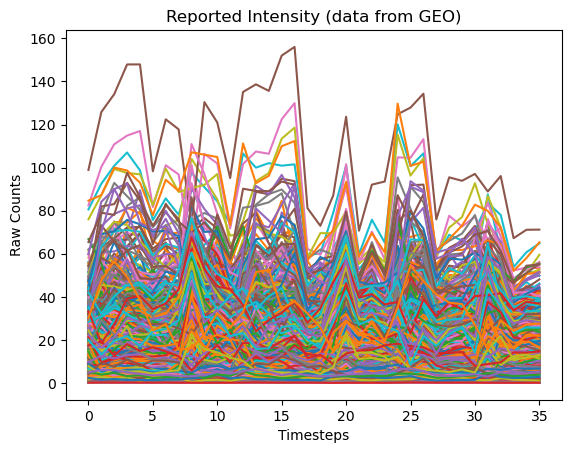

In [3]:
t_steps = np.arange(len(data))
plt.plot(t_steps, data)
plt.xlabel("Timesteps")
plt.ylabel("Raw Counts")
plt.title("Reported Intensity (data from GEO)")

In [4]:
# try normalizing by chip
medians = data.quantile(0.5, axis=1)   # chip median expressions
display(medians.sort_values().head())
display(medians.sort_values().tail())

# it appears that the median normalization may already have occured, but with a slightly different set of genes?
# we can go ahead and perform this normalization again anyway.
data = (data.T / medians.T).T
medians = data.quantile(0.5, axis=1)   # chip median expressions
display(medians.sort_values().head())
display(medians.sort_values().tail())

GSM77316    1.001011
GSM77325    1.001014
GSM77324    1.001131
GSM77323    1.001183
GSM77306    1.001211
Name: 0.5, dtype: float64

GSM77331    1.004921
GSM77315    1.005102
GSM77305    1.005225
GSM77317    1.005400
GSM77303    1.006536
Name: 0.5, dtype: float64

GSM77298    1.0
GSM77299    1.0
GSM77300    1.0
GSM77301    1.0
GSM77302    1.0
Name: 0.5, dtype: float64

GSM77329    1.0
GSM77330    1.0
GSM77331    1.0
GSM77332    1.0
GSM77333    1.0
Name: 0.5, dtype: float64

In [ ]:
data.to_csv("normalized-perchip.csv")

Text(0.5, 1.0, 'Arcsinh-Transformed Intensity')

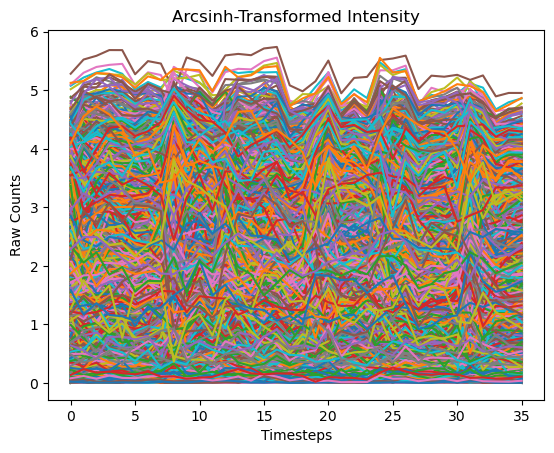

In [5]:
# now grab the arcsinh transform of the data
data = np.arcsinh(data)

t_steps = np.arange(len(data))
plt.plot(t_steps, data)
plt.xlabel("Timesteps")
plt.ylabel("Raw Counts")
plt.title("Arcsinh-Transformed Intensity")

In [6]:
# export this data
data.to_csv("normalized-perchip-arcsinh.csv")

In [10]:
# perform autocorrelation for 12-timestep period
autocorr = data.apply(lambda col: col.autocorr(12), axis=0)
display(autocorr)

# perform autocorrelations for 100 permutations of the timesteps for permutation testing
order = np.arange(len(data))
nperms = 100
perms = list()
for i in range(nperms):
    # shuffle the order
    np.random.shuffle(order)
    # autocorrelation on this shuffled columns
    perms.append(data.iloc[order, :].apply(lambda col: col.autocorr(12), axis=0))

ID_REF
10000_at      0.302403
10001_at      0.856806
10002_i_at    0.271246
10003_f_at    0.733451
10004_at      0.222313
                ...   
9995_at       0.750375
9996_at       0.869693
9997_at       0.542253
9998_at       0.794300
9999_at       0.752560
Length: 9275, dtype: float64

In [11]:
permsdf = pd.DataFrame(perms)
display(permsdf)

ID_REF,10000_at,10001_at,10002_i_at,10003_f_at,10004_at,10005_at,10006_at,10007_at,10008_at,10009_at,...,9990_at,9991_at,9992_at,9993_at,9994_at,9995_at,9996_at,9997_at,9998_at,9999_at
0,0.007374,0.319487,-0.242521,-0.066596,-0.331635,0.113747,0.078933,-0.076066,-0.192949,-0.041082,...,0.045722,-0.246317,-0.106630,-0.154749,-0.324050,0.264117,0.125956,0.069701,-0.029888,-0.000038
1,-0.258055,0.106959,0.114607,0.232978,-0.267394,0.352605,0.245912,-0.206430,-0.171139,0.068478,...,0.460090,-0.317064,0.539815,-0.123119,0.221229,0.179410,-0.221258,0.083054,-0.215562,0.154236
2,-0.027377,0.092763,-0.038048,0.281024,0.139229,-0.034279,-0.112394,0.044701,0.005752,0.197009,...,-0.225364,-0.207602,-0.224824,-0.370902,0.235333,0.321513,0.286871,-0.041337,0.263012,0.083803
3,-0.176718,-0.256330,-0.278759,-0.296181,0.072216,-0.359152,-0.326059,-0.287937,0.272717,0.094253,...,-0.220963,0.053874,-0.243836,-0.412868,0.042151,-0.353294,-0.224954,-0.401590,-0.068391,-0.173617
4,0.174202,0.099373,0.058009,-0.118454,0.016074,-0.099580,0.036871,0.065193,0.118347,-0.044732,...,-0.070048,-0.179029,0.094310,0.230103,-0.171361,-0.204288,-0.413788,0.077978,-0.330911,0.039306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.439993,-0.061387,0.185694,-0.397974,0.047464,-0.141893,0.022151,0.007412,-0.216850,0.109820,...,0.022844,-0.029247,-0.236913,0.338846,-0.191532,-0.105736,-0.104472,-0.290033,-0.089576,-0.275385
96,0.004794,-0.085784,-0.434671,-0.216678,0.076078,-0.089984,-0.286693,-0.252342,0.177902,-0.371907,...,0.078348,0.018070,0.033610,-0.141225,-0.188757,0.043777,-0.196398,-0.056897,-0.269412,-0.174845
97,0.059564,-0.181269,-0.227334,-0.094477,-0.194412,-0.224178,-0.251770,0.049056,-0.155012,-0.127227,...,0.086190,-0.015876,0.047273,-0.120285,-0.232869,-0.155991,-0.009324,0.021840,-0.031222,-0.097450
98,-0.098474,0.190641,0.028314,0.066604,0.160820,0.013719,0.018627,0.084089,0.427105,-0.047158,...,0.227370,-0.148914,0.115802,-0.405176,0.228156,0.018214,-0.026261,-0.263085,0.123410,-0.078444


In [ ]:
# count how many autocorrelations were greater in magnitude than the ones we observed
thresh = autocorr.abs()
tests = permsdf.abs()
bools = tests > thresh

# threshold: 5%
alpha = 0.05
periodic = bools.sum(axis=0) <= alpha * nperms

display(periodic)
display(int(periodic.sum()))

ID_REF
10000_at      False
10001_at       True
10002_i_at    False
10003_f_at     True
10004_at      False
              ...  
9995_at        True
9996_at        True
9997_at        True
9998_at        True
9999_at        True
Length: 9275, dtype: bool

5236

In [21]:
# subset the data
peridata = data.loc[:, periodic]
display(peridata)

ID_REF,10001_at,10003_f_at,10005_at,10006_at,10010_at,10011_at,10012_at,10013_at,10015_at,10016_at,...,9984_at,9986_at,9989_at,9992_at,9994_at,9995_at,9996_at,9997_at,9998_at,9999_at
GSM77298,1.437047,3.803361,1.533861,0.614774,4.087141,0.260326,1.237550,0.650351,2.297707,1.908454,...,0.533632,1.512223,0.641057,0.487771,3.685886,1.585712,4.093568,2.347292,0.136301,2.288447
GSM77299,1.351225,3.097790,1.398911,0.598074,3.974576,0.116232,1.881788,0.805176,2.894462,1.656402,...,0.580460,1.504362,0.554730,0.350344,3.269344,1.169223,4.554970,2.056239,0.236542,2.491590
GSM77300,0.997280,3.679443,1.594438,0.615066,4.162059,0.169069,2.022182,0.918515,3.341114,1.799657,...,0.792192,1.358442,0.410774,0.414943,3.668934,1.362803,4.725811,2.231584,0.175764,2.492338
GSM77301,0.980137,3.553888,1.369467,0.811451,3.803687,0.150941,2.008162,0.838681,2.900853,1.819865,...,0.590263,1.485986,0.783715,0.549871,3.770282,1.160348,4.587313,1.850947,0.194066,2.309352
GSM77302,0.836380,3.535727,1.315025,0.966502,3.442702,0.148226,2.105239,0.836380,2.927808,1.703871,...,0.521851,1.412698,0.792482,0.317885,3.537029,1.138892,4.341968,1.980670,0.167008,2.127815
GSM77303,0.826778,3.599009,1.373747,0.877542,3.058513,0.076764,2.130567,0.876774,2.584869,1.523012,...,0.375325,1.282124,0.742609,0.697471,3.867119,1.058365,3.878191,1.560221,0.146660,1.962445
GSM77304,0.761114,3.659863,1.291188,0.927984,3.396971,0.161460,2.140608,0.865229,2.374736,1.755045,...,0.561395,1.412258,0.799597,0.759455,3.910779,1.252416,3.998844,1.744466,0.192326,2.030064
GSM77305,0.924795,3.866385,1.445029,0.893814,3.214069,0.100662,1.799876,0.875481,2.581506,1.933529,...,0.257036,1.478418,0.488637,0.891627,4.059844,1.288954,3.424599,1.738230,0.106865,1.868203
GSM77306,1.883680,4.604133,1.871753,1.790942,3.307293,0.176828,1.159716,1.145829,3.210734,1.674939,...,0.369978,1.207108,0.910985,0.932581,4.626182,1.495408,3.471977,2.144238,0.112219,1.859690
GSM77307,1.270484,4.196536,1.409092,0.472189,3.716888,0.203295,1.232627,0.454037,2.820451,1.397164,...,0.316821,1.231424,0.618618,0.382131,4.113193,1.650963,3.803873,1.540347,0.071527,2.008170


In [22]:
# export this data
data.to_csv("periodic-normalized-perchip-arcsinh.csv")